In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import eloUtils
import gc
import datetime

In [185]:
#Data obtained from this script https://github.com/Nathanlauga/nba-data-scrapping/
games = pd.read_csv('games.csv',nrows=26300)
games_details = pd.read_csv('games_details.csv')
players = pd.read_csv('players.csv')
teams = pd.read_csv('teams.csv')
ranking = pd.read_csv('ranking.csv')
games['GAME_DATE_EST'] = pd.to_datetime(games['GAME_DATE_EST'])




/var/folders/sd/hj4zy7490lv2rrwbsv294vcw0000gp/T/ipykernel_72845/1543253632.py:3: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  games_details = pd.read_csv('games_details.csv')


In [27]:
games.tail()

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
22196,2006-11-01,20600012,Final,1610612762,1610612745,2006,1610612762,107.0,0.527,0.839,...,19.0,47.0,1610612745,97.0,0.432,0.639,0.455,19.0,36.0,1
22197,2006-11-01,20600013,Final,1610612760,1610612757,2006,1610612760,106.0,0.456,0.900,...,23.0,34.0,1610612757,110.0,0.548,0.800,0.200,13.0,40.0,0
22198,2006-11-01,20600007,Final,1610612751,1610612761,2006,1610612751,102.0,0.513,0.792,...,28.0,52.0,1610612761,92.0,0.394,0.700,0.200,21.0,38.0,1
22199,2006-10-31,20600001,Final,1610612748,1610612741,2006,1610612748,66.0,0.385,0.591,...,13.0,29.0,1610612741,108.0,0.494,0.719,0.538,22.0,49.0,0
22200,2006-10-31,20600002,Final,1610612747,1610612756,2006,1610612747,114.0,0.554,0.667,...,30.0,43.0,1610612756,106.0,0.519,0.765,0.433,29.0,29.0,1


In [186]:
gc.collect()

17952

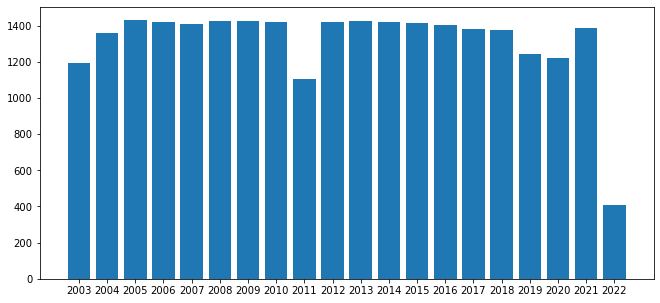

In [4]:
fig, ax = plt.subplots(figsize=(11,5))

v_c = games['SEASON'].value_counts().sort_index()
v_c.index = v_c.index.astype(str)
ax.bar(v_c.index, v_c.values)

plt.show()

In [187]:
def get_avg_stats_last_n_games(team, game_date, season_team_stats, n) :
  prev_game_df = season_team_stats[(season_team_stats['GAME_DATE_EST'] < game_date) & (season_team_stats['TEAM_ID_home'] == team) | (season_team_stats['TEAM_ID_home'] == team)].head(n)
  data = []
  for index,prev_game_row in prev_game_df.iterrows():
    if(prev_game_row['TEAM_ID_home'] == team):
        h_df = prev_game_row[[7,8,9,10,11,12]]
        data.append(h_df.tolist())
    if(prev_game_row['TEAM_ID_away']==team):
            #h_df.columns = [x[2:] for x in h_df.columns]   
        a_df = prev_game_row[[14,15,16,17,18,19]]
        data.append(a_df.tolist())
  ndf = pd.DataFrame(data, columns=['PTS', 'FG_PCT', 'FT_PCT','FG3_PCT','AST','REB'])          

  return ndf.mean()

The eloUtils.py file contains the helper methods to calculate elo and reset each teams ELO after each season. Having the file in the working directory should be fine, which would allow this notebook to find the helper functions. The cell below creates features for each game.

In [189]:
#Code to calculate ELO adapted from this article https://medium.com/mlearning-ai/how-to-calculate-elo-score-for-international-teams-using-python-66c136f01048
# Creating the empty dictionary that is going to store the current elo for each team
import eloUtils
current_elo={}
recentTeamPerformance = {}
games =  games.loc[::-1]
performance_data = []
recent_performance_df = pd.DataFrame()
curr_season = 2003
for idx,row in games.iterrows():
    # Getting the data that it is nedeed to calculate the elo 
    home=row['TEAM_ID_home']
    away=row['TEAM_ID_away']
    home_pts=row['PTS_home']
    away_pts=row['PTS_away']
    game_date = row['GAME_DATE_EST']
    game_id = row['GAME_ID']
    season = row['SEASON']
    
    if season != curr_season:
        curr_season = season
        for key in current_elo.keys():
            final_season_elo = current_elo[key]
            current_elo[key] = eloUtils.soft_reset(final_season_elo)



    # Getting elo before match. If it is the first match played, the elo is initialized in 1500.
    if home not in current_elo.keys():
        current_elo[home]=1500
    
    if away not in current_elo.keys():
        current_elo[away]=1500
    
    #calculating and updating elo
    elo_h=current_elo[home]
    elo_aw=current_elo[away]
    elo_ln,elo_vn=eloUtils.calculate_elo(elo_h,elo_aw,home_pts,away_pts)

    current_elo[home]=elo_ln
    current_elo[away]=elo_vn

    h_team_recent_performance = get_avg_stats_last_n_games(home, game_date, games, 5)
    #h_team_recent_performance.index = ['H_Last_10_Avg_' + x for x in h_team_recent_performance.index]
    recentTeamPerformance[home]=h_team_recent_performance.tolist()


    a_team_recent_performance = get_avg_stats_last_n_games(away, game_date, games, 5)
    recentTeamPerformance[away] = a_team_recent_performance.tolist()
    
    #a_team_recent_performance.index = ['A_Last_10_Avg_' + x for x in a_team_recent_performance.index]
    performance_data.append(h_team_recent_performance.tolist() +a_team_recent_performance.tolist())

    
    #Saving results in dataframe
    games.loc[idx,'Elo_h_after']=elo_ln
    games.loc[idx,'Elo_a_after']=elo_vn 
    games.loc[idx,'Elo_h_before']=elo_h
    games.loc[idx,'Elo_a_before']=elo_aw

    
recent_performance_df = pd.DataFrame(performance_data, columns= ['H_Last_10_Avg_PTS', 'H_Last_10_Avg_FG_PCT', 'H_Last_10_Avg_FT_PCT','H_Last_10_Avg_FG3_PCT','H_Last_10_Avg_AST','H_Last_10_Avg_REB','A_Last_10_Avg_PTS', 'A_Last_10_Avg_FG_PCT', 'A_Last_10_Avg_FT_PCT','A_Last_10_Avg_FG3_PCT','A_Last_10_Avg_AST','A_Last_10_Avg_REB'])
recent_performance_df.reset_index(drop=True, inplace=True)
games.reset_index(drop=True, inplace=True)
featureGames = pd.concat([games, recent_performance_df], axis = 1)
games =  games.loc[::-1]
featureGames =  featureGames.loc[::-1]


### Add Betting Data

In [259]:
bettingGames = featureGames.loc[((games['GAME_DATE_EST']>= datetime.datetime(2006, 10, 31)) & (games['GAME_DATE_EST'] <=datetime.datetime(2022, 12, 5)))]
bettingGames.sort_values(by = ['GAME_DATE_EST','TEAM_ID_home'],  ascending=True).reset_index(drop=True)

moneylines = pd.read_csv('/Users/jfong/Documents/GitHub/NBA-Prediction-Model/data/all_moneylines_sbr.csv', parse_dates=['game_date'])
from make_betting_dataset import clean_moneyline_data

clean_moneylines = clean_moneyline_data(moneylines)
teamIDMap = dict(zip(teams.ABBREVIATION, teams.TEAM_ID))
clean_moneylines['home_team'] = clean_moneylines['home_team'].replace(teamIDMap)
clean_moneylines['away_team'] = clean_moneylines['away_team'].replace(teamIDMap)
clean_moneylines.rename(columns={'away_team' :'TEAM_ID_away' ,'home_team': 'TEAM_ID_home','game_date' : 'GAME_DATE_EST',}, inplace=True)


             0        1        2        3
0      ['+180'      '-'   '+180'     '-']
1      ['-380'      '-'   '-350'     '-']
2         ['-'      '-'   '-120'     '-']
3      ['+165'      '-'   '+155'     '-']
4      ['+245'      '-'   '+250'     '-']
...        ...      ...      ...      ...
20616  ['+110'   '+100'   '+104'   '+110'
20617  ['+260'   '+245'   '+265'   '+270'
20618  ['+550'   '+575'   '+600'   '+600'
20619  ['-140'   '-140'   '-162'   '-141'
20620  ['+310'   '+290'   '+285'   '+310'

[20621 rows x 4 columns]


/Users/jfong/Documents/GitHub/NBA-Prediction-Model/notebooks/make_betting_dataset.py:64: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  ml_df[col] = ml_df[col].str.replace('[', '')
/Users/jfong/Documents/GitHub/NBA-Prediction-Model/notebooks/make_betting_dataset.py:65: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  ml_df[col] = ml_df[col].str.replace(']', '')


In [260]:

clean_moneylines['GAME_DATE_EST'] = pd.to_datetime(clean_moneylines['GAME_DATE_EST'])
clean_moneylines.sort_values(by = ['GAME_DATE_EST','TEAM_ID_home'],  ascending=True).reset_index(drop=True)



,TEAM_ID_away,TEAM_ID_home,GAME_DATE_EST,away_ml1,away_ml2,away_ml3,away_ml4,home_ml1,home_ml2,home_ml3,home_ml4
0,1610612756,1610612747,2006-10-31,-380,NaN,-350,NaN,+290,NaN,+290,NaN
1,1610612741,1610612748,2006-10-31,+180,NaN,+180,NaN,-220,NaN,-210,NaN
2,1610612740,1610612738,2006-11-01,+140,NaN,+140,NaN,-160,NaN,-160,NaN
3,1610612764,1610612739,2006-11-01,+210,NaN,+215,NaN,-250,NaN,-255,NaN
4,1610612747,1610612744,2006-11-01,+245,NaN,+250,NaN,-290,NaN,-300,NaN
...,...,...,...,...,...,...,...,...,...,...,...
20616,1610612754,1610612757,2022-12-04,+165,+170,+180,+170,-200,-200,-215,-204
20617,1610612741,1610612758,2022-12-04,+120,+125,+126,+130,-145,-145,-148,-154
20618,1610612756,1610612759,2022-12-04,-450,-490,-500,-476,+333,+390,+385,+360
20619,1610612747,1610612764,2022-12-04,+105,+110,+110,+110,-130,-130,-130,-130


In [261]:
def convert_american_to_decimal(x):
    if (np.isnan(x) == False):
        return np.where(x>0, (100+x)/100, 1+(100.0/-x)) 
    else:
        return x

def clean_moneyline_df(df=moneylines):

    away_mls = df.loc[:,['away_ml1', 'away_ml2', 'away_ml3',
       'away_ml4']]
    home_mls = df.loc[:,['home_ml1', 'home_ml2', 'home_ml3', 'home_ml4']]

    away_mls = away_mls.replace('-', np.nan).replace('', np.nan)
    away_mls = away_mls.fillna(value=np.nan)
    away_mls = away_mls.astype(float)

    home_mls = home_mls.replace('-', np.nan).replace('', np.nan)
    home_mls = home_mls.fillna(value=np.nan)
    home_mls = home_mls.astype(float)
 
    avg_away_ml = away_mls.apply(lambda row: row.map(lambda x: convert_american_to_decimal(x) if pd.notnull(x) else x), axis = 1)
    print(avg_away_ml)
    avg_away_ml = avg_away_ml.apply(lambda row: np.nanmean(row), axis = 1)
    print(avg_away_ml)
    avg_away_ml = pd.DataFrame(
        avg_away_ml, columns=['avg_away_ml'])
    avg_home_ml = home_mls.apply(lambda row: row.map(lambda x: convert_american_to_decimal(x) if pd.notnull(x) else x), axis = 1)
    avg_home_ml = avg_home_ml.apply(lambda row: np.nanmean(row), axis = 1)
    avg_home_ml = pd.DataFrame(
        avg_home_ml, columns=['avg_home_ml'])

    moneylines = pd.concat(
        [df.iloc[:, :3], avg_home_ml, avg_away_ml], axis=1)

    return moneylines

In [293]:
clean_mls = clean_moneyline_df(df=clean_moneylines)
clean_mls.dropna(how='any', inplace=True)
clean_mls.sort_values(by = 'GAME_DATE_EST', ascending= False)
bettingGames.sort_values(by = 'GAME_DATE_EST', ascending= False)
clean_mls.shape

       away_ml1  away_ml2  away_ml3  away_ml4
0      2.800000       NaN  2.800000       NaN
1      1.263158       NaN  1.285714       NaN
2           NaN       NaN  1.833333       NaN
3      2.650000       NaN  2.550000       NaN
4      3.450000       NaN  3.500000       NaN
...         ...       ...       ...       ...
20616  2.100000  2.000000  2.040000   2.10000
20617  3.600000  3.450000  3.650000   3.70000
20618  6.500000  6.750000  7.000000   7.00000
20619  1.714286  1.714286  1.617284   1.70922
20620  4.100000  3.900000  3.850000   4.10000

[20621 rows x 4 columns]


/var/folders/sd/hj4zy7490lv2rrwbsv294vcw0000gp/T/ipykernel_72845/1178002923.py:23: RuntimeWarning: Mean of empty slice
  avg_away_ml = avg_away_ml.apply(lambda row: np.nanmean(row), axis = 1)


0        2.800000
1        1.274436
2        1.833333
3        2.600000
4        3.475000
           ...   
20616    2.060000
20617    3.600000
20618    6.812500
20619    1.688769
20620    3.987500
Length: 20621, dtype: float64


/var/folders/sd/hj4zy7490lv2rrwbsv294vcw0000gp/T/ipykernel_72845/1178002923.py:28: RuntimeWarning: Mean of empty slice
  avg_home_ml = avg_home_ml.apply(lambda row: np.nanmean(row), axis = 1)


(18602, 5)

In [273]:

print(bettingGames.iloc[6250:])
clean_mls.iloc[6250:]

      GAME_DATE_EST   GAME_ID GAME_STATUS_TEXT  HOME_TEAM_ID  VISITOR_TEAM_ID  \
15958    2011-01-13  21000575            Final    1610612743       1610612748   
15957    2011-01-13  21000574            Final    1610612760       1610612753   
15956    2011-01-13  21000573            Final    1610612750       1610612764   
15955    2011-01-14  21000586            Final    1610612747       1610612751   
15954    2011-01-14  21000585            Final    1610612744       1610612746   
...             ...       ...              ...           ...              ...   
4        2022-12-04  22200348            Final    1610612752       1610612739   
3        2022-12-04  22200347            Final    1610612765       1610612763   
2        2022-12-04  22200346            Final    1610612751       1610612738   
1        2022-12-04  22200345            Final    1610612759       1610612756   
0        2022-12-04  22200344            Final    1610612740       1610612743   

       SEASON  TEAM_ID_home

,TEAM_ID_away,TEAM_ID_home,GAME_DATE_EST,avg_home_ml,avg_away_ml
6941,1610612764,1610612738,2012-03-25,1.198039,5.075000
6942,1610612743,1610612750,2012-03-25,1.816667,2.025000
6943,1610612762,1610612737,2012-03-25,1.851449,1.976190
6944,1610612748,1610612760,2012-03-25,1.800000,2.050000
6945,1610612744,1610612757,2012-03-25,1.165181,5.416667
...,...,...,...,...,...
20616,1610612737,1610612761,2022-10-31,1.774719,2.060000
20617,1610612754,1610612751,2022-10-31,1.299015,3.600000
20618,1610612765,1610612749,2022-10-31,1.110051,6.812500
20619,1610612763,1610612762,2022-10-31,2.222500,1.688769


In [311]:
bettingdf = pd.merge(bettingGames, clean_mls, on= ['GAME_DATE_EST', 'TEAM_ID_home','TEAM_ID_away'], how='inner')
bettingdf.sort_values(by = 'GAME_DATE_EST').reset_index()
bettingdf.dropna(how='any', inplace=True)


In [295]:

bettingdf.shape

(18588, 39)

In [409]:
cutoff_18 = int(bettingdf[bettingdf['SEASON'] == 2018].index[0])
cutoff_19 = int(bettingdf[bettingdf['SEASON'] == 2019].index[0])
cutoff_20 = int(bettingdf[bettingdf['SEASON'] == 2020].index[0])
cutoff_21 = int(bettingdf[bettingdf['SEASON'] == 2021].index[0])
cutoff_17 = int(bettingdf[bettingdf['SEASON'] == 2017].index[0])
cutoff_16 = int(bettingdf[bettingdf['SEASON'] == 2016].index[0])
cutoff_22 = int(bettingdf[bettingdf['SEASON'] == 2022].index[0])
cutoffs = [cutoff_16,cutoff_17,cutoff_18, cutoff_19, cutoff_20,cutoff_21,cutoff_22]
print(cutoffs)

[11143, 12310, 13522, 14732, 15780, 16920, 18237]


In [332]:
bettingdf.shape


(18588, 39)

In [333]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import normalize, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.pipeline import Pipeline



cols = ['Elo_h_before','Elo_a_before','H_Last_10_Avg_PTS', 'H_Last_10_Avg_FG_PCT', 'H_Last_10_Avg_FT_PCT','H_Last_10_Avg_FG3_PCT','H_Last_10_Avg_AST','H_Last_10_Avg_REB','A_Last_10_Avg_PTS', 'A_Last_10_Avg_FG_PCT', 'A_Last_10_Avg_FT_PCT','A_Last_10_Avg_FG3_PCT','A_Last_10_Avg_AST','A_Last_10_Avg_REB']

features = bettingdf[cols].values
label = bettingdf['HOME_TEAM_WINS'].values

features1 = bettingdf[cols].copy()

features1.tail()


,Elo_h_before,Elo_a_before,H_Last_10_Avg_PTS,H_Last_10_Avg_FG_PCT,H_Last_10_Avg_FT_PCT,H_Last_10_Avg_FG3_PCT,H_Last_10_Avg_AST,H_Last_10_Avg_REB,A_Last_10_Avg_PTS,A_Last_10_Avg_FG_PCT,A_Last_10_Avg_FT_PCT,A_Last_10_Avg_FG3_PCT,A_Last_10_Avg_AST,A_Last_10_Avg_REB
18583,1500.0,1500.0,109.4,0.4452,0.7728,0.2690,22.0,48.0,112.2,0.5560,0.8580,0.4438,25.4,39.6
18584,1500.0,1500.0,111.6,0.4800,0.6650,0.3484,24.0,39.2,118.6,0.4638,0.7178,0.3358,25.0,51.0
18585,1500.0,1500.0,107.8,0.4950,0.7844,0.3726,22.6,40.2,128.4,0.5298,0.8732,0.4374,30.0,40.8
18586,1500.0,1500.0,107.2,0.4384,0.7130,0.2876,26.0,44.6,117.8,0.4934,0.7326,0.3798,24.6,44.6
18587,1500.0,1500.0,117.8,0.5018,0.8014,0.3712,26.4,44.8,117.2,0.5292,0.7208,0.4158,28.8,43.2


In [299]:

bettingdf.iloc[cutoffs[0]:,:]

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,H_Last_10_Avg_AST,H_Last_10_Avg_REB,A_Last_10_Avg_PTS,A_Last_10_Avg_FG_PCT,A_Last_10_Avg_FT_PCT,A_Last_10_Avg_FG3_PCT,A_Last_10_Avg_AST,A_Last_10_Avg_REB,avg_home_ml,avg_away_ml
11143,2016-10-25,21600003,Final,1610612744,1610612759,2016,1610612744,100.0,0.471,0.722,...,33.4,46.0,107.2,0.4384,0.7130,0.2876,26.0,44.6,1.239920,4.287500
11144,2016-10-26,21600013,Final,1610612747,1610612745,2016,1610612747,120.0,0.506,0.818,...,26.8,49.6,112.6,0.4480,0.7704,0.3380,21.8,49.2,3.037500,1.410465
11145,2016-10-26,21600012,Final,1610612756,1610612758,2016,1610612756,94.0,0.468,0.667,...,24.6,44.6,126.2,0.5248,0.8898,0.3554,29.4,43.8,1.663399,2.307500
11146,2016-10-26,21600011,Final,1610612755,1610612760,2016,1610612755,97.0,0.429,0.720,...,22.4,41.0,123.8,0.4910,0.7890,0.3548,24.6,44.6,4.837500,1.200823
11147,2016-10-26,21600010,Final,1610612740,1610612743,2016,1610612740,102.0,0.413,0.885,...,26.4,44.8,117.2,0.5292,0.7208,0.4158,28.8,43.2,1.825000,2.012500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18583,2022-12-04,22200348,Final,1610612752,1610612739,2022,1610612752,92.0,0.407,0.810,...,22.0,48.0,112.2,0.5560,0.8580,0.4438,25.4,39.6,2.187500,1.710716
18584,2022-12-04,22200347,Final,1610612765,1610612763,2022,1610612765,112.0,0.440,0.833,...,24.0,39.2,118.6,0.4638,0.7178,0.3358,25.0,51.0,3.137500,1.382045
18585,2022-12-04,22200346,Final,1610612751,1610612738,2022,1610612751,92.0,0.405,0.682,...,22.6,40.2,128.4,0.5298,0.8732,0.4374,30.0,40.8,2.147500,1.735509
18586,2022-12-04,22200345,Final,1610612759,1610612756,2022,1610612759,95.0,0.437,0.722,...,26.0,44.6,117.8,0.4934,0.7326,0.3798,24.6,44.6,4.670000,1.209097


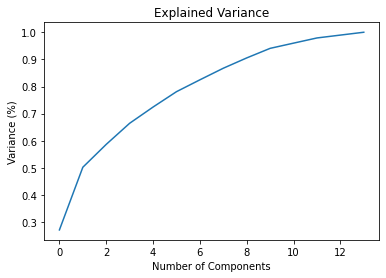

In [97]:
# scaler = RobustScaler()
# features_scaled = scaler.fit_transform(features)

# #Fitting the PCA algorithm with our Data
# pca = PCA().fit(features_scaled)
# #Plotting the Cumulative Summation of the Explained Variance
# plt.figure()
# plt.plot(np.cumsum(pca.explained_variance_ratio_))
# plt.xlabel('Number of Components')
# plt.ylabel('Variance (%)') #for each component
# plt.title('Explained Variance')
# plt.show()

### Data Analysis:

In this section, I test the performance of Gaussian Native Bayes, K-Nearest Neighbors, Decision Tree, and Random Forest and an Ensemble of the best performers. (Bagging, Boosting, vs. Stacking) ELO already gives a good idea of a team's likelihood of winning, where if the model simply picked the team with the highest ELO, it will often result in an accurate prediction most of the time. Focusing more on improving the F1-score of the model would reduce the number of false positives and negatives, and would be a better metric to evaluate the overall performance of the model.

In [135]:
from sklearn.metrics import make_scorer,f1_score
# features_pca = PCA(14).fit_transform(features_scaled)
x_train, x_test, y_train, y_test = train_test_split(features, label, test_size = 0.2)
# x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.1)

scorer = make_scorer(f1_score, pos_label=None, average='weighted')

In [42]:
from sklearn.naive_bayes import GaussianNB
pipelineNB= Pipeline([('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf', GaussianNB(var_smoothing=.01))])
                   
pipelineNB.fit(x_train, y_train)
y_train_NB = pipelineNB.predict(x_train)
y_pred_NB = pipelineNB.predict(x_test)



In [43]:
print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_NB)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_NB)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_NB)))

Train Accuracy score: 0.6638783269961978
Test Accuracy score: 0.6629277566539924
Test F1 score: 0.740751571867232


In [106]:
pipelinerf = Pipeline(steps=[('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf', RandomForestClassifier(max_depth=3, max_features='sqrt', min_samples_leaf=4,
                         min_samples_split=4, n_estimators=473, n_jobs=2))])

pipelinerf.fit(x_train, y_train)
y_train_rf = pipelinerf.predict(x_train)
y_pred_rf = pipelinerf.predict(x_test)


In [107]:
print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_rf)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_rf)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_rf)))

Train Accuracy score: 0.6345532319391635
Test Accuracy score: 0.6317490494296578
Test F1 score: 0.7510602750289165


In [108]:
from sklearn.calibration import CalibratedClassifierCV
isotonicRFC = Pipeline(steps=[('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf',CalibratedClassifierCV(pipelinerf,cv = 5, method = "isotonic"))])

isotonicRFC.fit(x_train, y_train)
y_train_iso = isotonicRFC.predict(x_train)
y_pred_iso = isotonicRFC.predict(x_test)
print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_iso)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_iso)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_iso)))



Train Accuracy score: 0.6645437262357414
Test Accuracy score: 0.6576045627376426
Test F1 score: 0.7390233299521809


The base Naive Bayes model performed the best out of the following models, with an accuracy of 65.5% on the test set, and a F1 score of .73, and the base RandomForestClassifier performed second best, with an an accuracy of 60.9% and an F1-score of .68.

In [44]:
#Tuning GaussianNB Code from: https://stackoverflow.com/questions/39828535/how-to-tune-gaussiannb
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
import numpy as np
params_NB = {
    'clf__priors': [None],
    'clf__var_smoothing': np.logspace(0,-9, num=100)
}

gs_NB = GridSearchCV(estimator=pipelineNB, 
                 param_grid=params_NB, 
                 cv=10,   # use any cross validation technique 
                 verbose=1, 
                 scoring='f1') 
gs_NB.fit(x_train, y_train)
print(gs_NB.best_estimator_)
y_train_NB_GS = gs_NB.predict(x_train)
y_pred_NB_GS = gs_NB.predict(x_test)


Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Pipeline(steps=[('scaler', RobustScaler()), ('pca', PCA(n_components=14)),
                ('clf', GaussianNB(var_smoothing=0.01))])


In [47]:
print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_NB_GS)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_NB_GS)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_NB_GS)))
print('Average Decision Tree F1: {}'.format((cross_val_score(gs_NB, x_train, y_train, scoring=scorer)).mean()))

Train Accuracy score: 0.663212927756654
Test Accuracy score: 0.661787072243346
Test F1 score: 0.741537120441668
Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Average Decision Tree F1: 0.6479029588131139


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 0, stop = 2000, num = 11)]
# Number of features to consider at every split
max_features = ['auto', 'sqrt']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(0, 100, num = 6)]
max_depth.append(None)
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4]
# Method of selecting samples for training each tree
bootstrap = [True, False]
# Create the random grid
random_grid = {'clf__n_estimators': n_estimators,
               'clf__max_features': max_features,
               'clf__max_depth': max_depth,
               'clf__min_samples_split': min_samples_split,
               'clf__min_samples_leaf': min_samples_leaf,
               'clf__bootstrap': bootstrap}


# Use the random grid to search for best hyperparameters

# Random search of parameters, using 2-fold cross validation, 
# search across 100 different combinations, and use all available cores
rfc_random = RandomizedSearchCV(estimator = pipelinerf, param_distributions = random_grid, n_iter = 100, cv = 2, verbose=2, n_jobs = -1)
# Fit the random search model
rfc_random.fit(x_train, y_train)
y_pred_rfr_random = rfc_random.predict(x_test)
print(metrics.accuracy_score(y_test, y_pred_rfr_random))


Fitting 2 folds for each of 100 candidates, totalling 200 fits


/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_m

[CV] END clf__bootstrap=False, clf__max_depth=100, clf__max_features=auto, clf__min_samples_leaf=1, clf__min_samples_split=2, clf__n_estimators=600; total time= 1.7min
[CV] END clf__bootstrap=False, clf__max_depth=100, clf__max_features=auto, clf__min_samples_leaf=1, clf__min_samples_split=2, clf__n_estimators=600; total time= 1.7min
[CV] END clf__bootstrap=False, clf__max_depth=60, clf__max_features=sqrt, clf__min_samples_leaf=2, clf__min_samples_split=2, clf__n_estimators=1000; total time= 3.2min
[CV] END clf__bootstrap=False, clf__max_depth=60, clf__max_features=sqrt, clf__min_samples_leaf=2, clf__min_samples_split=2, clf__n_estimators=1000; total time= 3.2min
[CV] END clf__bootstrap=True, clf__max_depth=0, clf__max_features=sqrt, clf__min_samples_leaf=4, clf__min_samples_split=2, clf__n_estimators=1600; total time=   1.5s
[CV] END clf__bootstrap=True, clf__max_depth=0, clf__max_features=sqrt, clf__min_samples_leaf=4, clf__min_samples_split=2, clf__n_estimators=1600; total time=   1

/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:372: FitFailedWarning: 
30 fits failed out of a total of 200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
8 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/pipeline.py", line 394, in fit
    self._final_estimator.fit(Xt, y, **fit_params_last_step)
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_forest.py", line 450, in fit
    trees = Parallel(
  File "/opt/anaconda3/lib/python3.9/si

0.638212927756654


In [395]:
# bettingdf.head()
bettingdf[['GAME_DATE_EST', 'avg_home_ml','avg_away_ml','HOME_TEAM_WINS']].iloc[cutoffs[i]:]

bettingdf.iloc[cutoffs[0]:cutoffs[1], :]

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,H_Last_10_Avg_AST,H_Last_10_Avg_REB,A_Last_10_Avg_PTS,A_Last_10_Avg_FG_PCT,A_Last_10_Avg_FT_PCT,A_Last_10_Avg_FG3_PCT,A_Last_10_Avg_AST,A_Last_10_Avg_REB,avg_home_ml,avg_away_ml
11143,2016-10-25,21600003,Final,1610612744,1610612759,2016,1610612744,100.0,0.471,0.722,...,33.4,46.0,107.2,0.4384,0.7130,0.2876,26.0,44.6,1.239920,4.287500
11144,2016-10-26,21600013,Final,1610612747,1610612745,2016,1610612747,120.0,0.506,0.818,...,26.8,49.6,112.6,0.4480,0.7704,0.3380,21.8,49.2,3.037500,1.410465
11145,2016-10-26,21600012,Final,1610612756,1610612758,2016,1610612756,94.0,0.468,0.667,...,24.6,44.6,126.2,0.5248,0.8898,0.3554,29.4,43.8,1.663399,2.307500
11146,2016-10-26,21600011,Final,1610612755,1610612760,2016,1610612755,97.0,0.429,0.720,...,22.4,41.0,123.8,0.4910,0.7890,0.3548,24.6,44.6,4.837500,1.200823
11147,2016-10-26,21600010,Final,1610612740,1610612743,2016,1610612740,102.0,0.413,0.885,...,26.4,44.8,117.2,0.5292,0.7208,0.4158,28.8,43.2,1.825000,2.012500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12305,2017-04-12,21601221,Final,1610612748,1610612764,2016,1610612748,110.0,0.523,0.833,...,24.0,45.2,118.8,0.4814,0.7806,0.3896,27.8,44.4,1.165751,5.482500
12306,2017-04-12,21601220,Final,1610612752,1610612755,2016,1610612752,114.0,0.494,0.719,...,22.0,48.0,108.6,0.4722,0.8016,0.3866,22.4,41.0,1.641682,2.357500
12307,2017-04-12,21601219,Final,1610612738,1610612749,2016,1610612738,112.0,0.456,0.692,...,30.0,40.8,120.4,0.5198,0.7306,0.3920,27.8,43.0,1.073374,9.392500
12308,2017-04-12,21601218,Final,1610612739,1610612761,2016,1610612739,83.0,0.368,0.708,...,25.4,39.6,107.2,0.4600,0.7770,0.3114,22.6,46.0,2.460000,1.601604


In [412]:


def kelly(prob_win, payout_perc):
    return (prob_win * payout_perc - (1 - prob_win)) / payout_perc

def expected_value(wager, prob_win, payout_perc):
    return (wager * payout_perc * prob_win) - (wager * (1-prob_win))

def pickKellyBet(prob_win,homePayout, awayPayout):
    kellyHome = kelly(prob_win,homePayout)
    kellyAway = kelly(1-prob_win,awayPayout)
    evH = expected_value(kellyHome,prob_win,homePayout)
    evA = expected_value(kellyAway,1-prob_win,awayPayout)
    if evH > evA:
        return 1
    else:
        return 0



def simulate_bets(df):
    df = df.reset_index()
    df.loc[0, 'bankroll_i'] = 100
    for idx in df.index:
        if np.isnan(df.loc[idx, 'bankroll_i']):
            df.loc[idx, 'bankroll_i'] = df.loc[idx-1, 'bankroll_n']
        
        payout = np.nan
        bet = df.loc[idx,'bets']
        # print(bet)
        probs = df.loc[idx, 'model_probability']

        if (bet == 1):
            payout = df.loc[idx,'avg_home_ml']
        else:
            payout = df.loc[idx,'avg_away_ml']
            probs = 1 - probs

        
        
        # print(probs)
        # print(payout)

        df.loc[idx, 'bet_size'] = df.loc[idx, 'bankroll_i'] * (0.25 * kelly(probs,payout))
        if df.loc[idx, 'bet_won'] == 1:
            df.loc[idx, 'bankroll_n'] = df.loc[idx, 'bankroll_i'] + (1/1.1)*df.loc[idx, 'bet_size']
        elif df.loc[idx, 'bet_won'] == 0:
            df.loc[idx, 'bankroll_n'] = df.loc[idx, 'bankroll_i'] - df.loc[idx, 'bet_size']
        else:
            df.loc[idx, 'bankroll_n'] = df.loc[idx, 'bankroll_i']
            
    plt.style.use('fivethirtyeight')

    fig, ax = plt.subplots(figsize=(12, 8))

    ax.plot(range(df.shape[0]), df['bankroll_i'], linewidth=1.5)            
    plt.show()
    min_balance = df['bankroll_n'].min()
    max_balance = df['bankroll_n'].max()
    final_balance = df['bankroll_n'].iloc[-1]
    win_pct = df.loc[df['bet_won'] != 0.5, 'bet_won'].mean()
    print("min balance:", min_balance,
         "\nmax balance:", max_balance,
         "\nfinal balance:", final_balance,
         "\nwin percentage", round(win_pct, 4) * 100)
    return df



In [410]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
betting_results = bettingdf[['GAME_DATE_EST', 'avg_home_ml','avg_away_ml']].copy()
# print(betting_results.iloc[:cutoffs[6], :])
# print(bettingdf.shape)
# print(features1.shape)
def train_model(features=features1):
    
    win = bettingdf['HOME_TEAM_WINS']
    
    result_dfs = []
    
    for i in range(len(cutoffs)):
        betting_results = bettingdf[['GAME_DATE_EST', 'avg_home_ml','avg_away_ml']].copy()
        if i == len(cutoffs) - 1:
            X_train = features.iloc[:cutoffs[i], :]
            X_test = features.iloc[cutoffs[i]:, :]
            ml_train = win[:cutoffs[i]]
            ml_test = win[cutoffs[i]:]
            betting_results = betting_results.iloc[cutoffs[i]:, :]
            print(X_test.shape)
        else:
            X_train = features.iloc[:cutoffs[i], :]
            X_test = features.iloc[cutoffs[i]:cutoffs[i+1], :]
            ml_train = win[:cutoffs[i]]
            ml_test = win[cutoffs[i]:cutoffs[i+1]]
            betting_results = betting_results.iloc[cutoffs[i]:cutoffs[i+1]]
            
            print(X_test.shape)
        
        
        pipelinerf = Pipeline(steps=[('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf', RandomForestClassifier(max_depth=3, max_features='sqrt', min_samples_leaf=4,
                         min_samples_split=4, n_estimators=473, n_jobs=2))])

        pipeline = Pipeline(steps=[('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf',CalibratedClassifierCV(pipelinerf,cv = 5, method = "isotonic"))])

        # pipeline = Pipeline(steps=[('scaler', RobustScaler()),
        #            ('pca', PCA(n_components=14)),
        #            ('clf', KNeighborsClassifier(n_neighbors=3))])

        pipeline.fit(X_train, ml_train)
        preds = pipeline.predict(X_test)
        probs = pipeline.predict_proba(X_test)

        train_accuracy = pipeline.score(X_train, ml_train)
        test_accuracy = pipeline.score(X_test, ml_test)
        print("season {}".format(i+2016))
        print("train_accuracy:", train_accuracy, "test_accuracy:", test_accuracy)

                
        if i == len(cutoffs) - 1:
            betting_results = bettingdf[['GAME_DATE_EST', 'avg_home_ml','avg_away_ml','HOME_TEAM_WINS']].iloc[cutoffs[i]:, :]
            
        else:
            betting_results = bettingdf[['GAME_DATE_EST', 'avg_home_ml','avg_away_ml','HOME_TEAM_WINS']].iloc[cutoffs[i]:cutoffs[i+1], :]
            
        betting_results['model_pred'] = preds
        betting_results['model_probability'] = probs[:, 1]
        betting_results['bets'] = betting_results.apply(lambda x: pickKellyBet(x.model_probability, x.avg_home_ml, x.avg_away_ml), axis=1)
        betting_results['bet_won'] = (betting_results['HOME_TEAM_WINS'] == betting_results['bets']).astype(int)

        betting_results['bankroll_i'] = np.nan
        betting_results['bankroll_n'] = np.nan
        betting_results['bet_size'] = np.nan
        

        select_bets = betting_results.loc[((betting_results['model_probability'] > 0.55)
                                         |(betting_results['model_probability'] < 0.45))]
        ranges = []
        win_percentages = []
        for i in range(1, 20):
            for j in range(1, 20):
                select_bets = betting_results.loc[(betting_results['model_probability'] > 0.5 + i/100)
                                          | (betting_results['model_probability'] < 0.5 - j/100)]
        
        win_pct = select_bets['bet_won'].mean()
        ranges.append((0.5-j/100, 0.5+i/100))
        win_percentages.append(win_pct)
        
        prob_ranges = pd.DataFrame({'probability_range':ranges, 'win_percentage':win_percentages})
        print(prob_ranges)
        
        
        results = simulate_bets(select_bets)
        result_dfs.append(results)
    return result_dfs

(1167, 14)
season 2016
train_accuracy: 0.686260432558557 test_accuracy: 0.6478149100257069
  probability_range  win_percentage
0      (0.31, 0.69)        0.737533


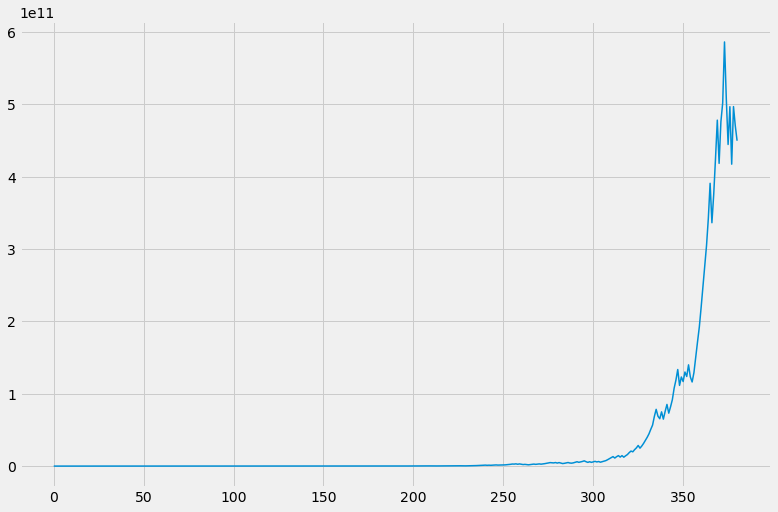

min balance: 76.9240110867205 
max balance: 586047339972.2045 
final balance: 499746478990.03394 
win percentage 73.75
(1212, 14)
season 2017
train_accuracy: 0.6837530463038181 test_accuracy: 0.6476897689768977
  probability_range  win_percentage
0      (0.31, 0.69)          0.7325


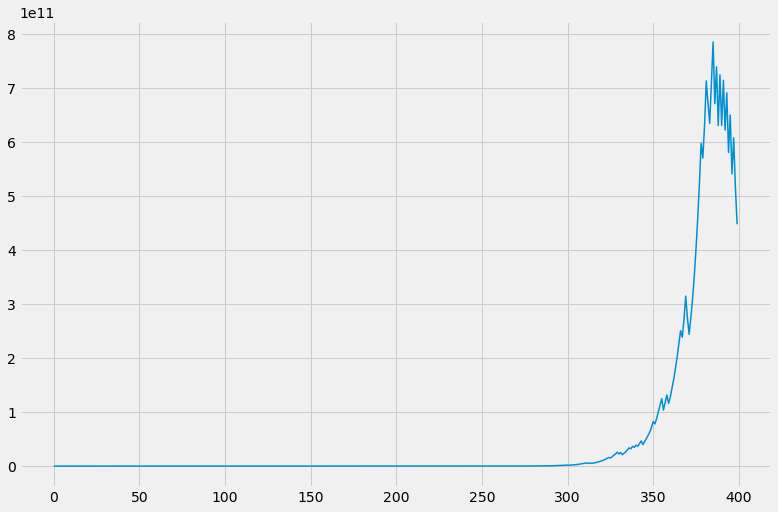

min balance: 84.66566292419797 
max balance: 785468856921.3912 
final balance: 387792519803.7241 
win percentage 73.25
(1210, 14)
season 2018
train_accuracy: 0.6821476113001035 test_accuracy: 0.6652892561983471
  probability_range  win_percentage
0      (0.31, 0.69)        0.742718


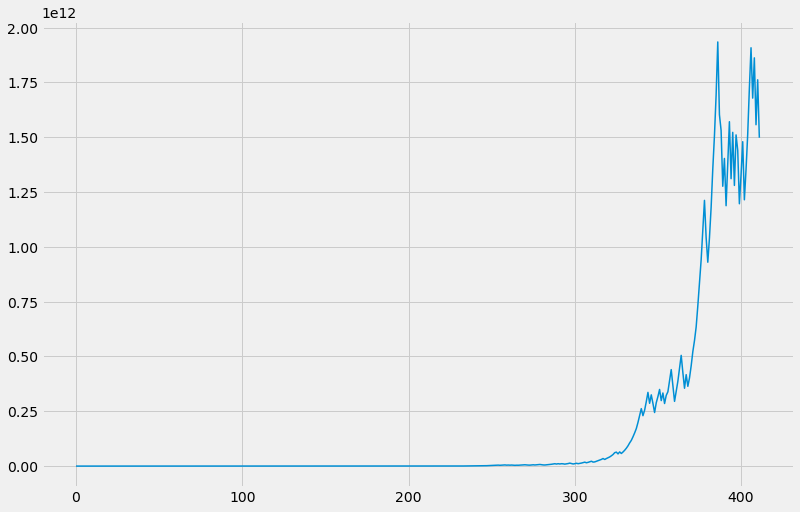

min balance: 85.83922683083713 
max balance: 1934840016217.319 
final balance: 1267523717987.6204 
win percentage 74.27
(1048, 14)
season 2019
train_accuracy: 0.6808987238664133 test_accuracy: 0.6230916030534351
  probability_range  win_percentage
0      (0.31, 0.69)        0.734824


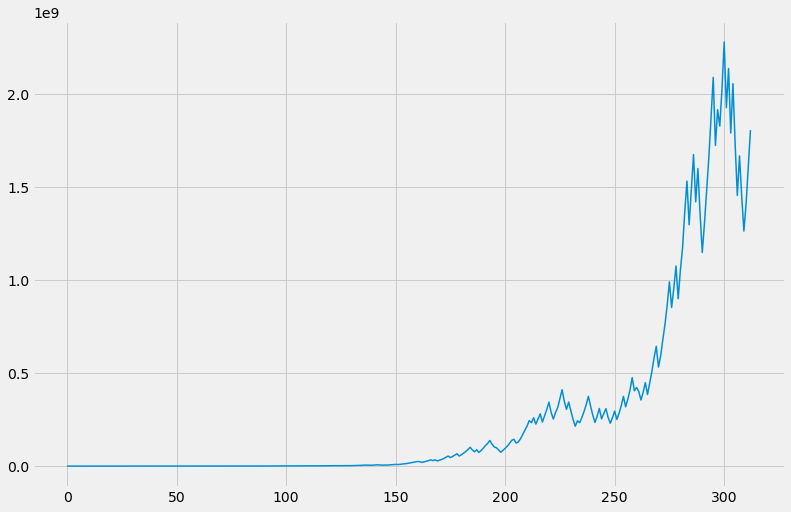

min balance: 115.81030552611537 
max balance: 2282002424.389114 
final balance: 1536918716.1686194 
win percentage 73.48
(1140, 14)
season 2020
train_accuracy: 0.6769961977186312 test_accuracy: 0.6070175438596491
  probability_range  win_percentage
0      (0.31, 0.69)        0.710227


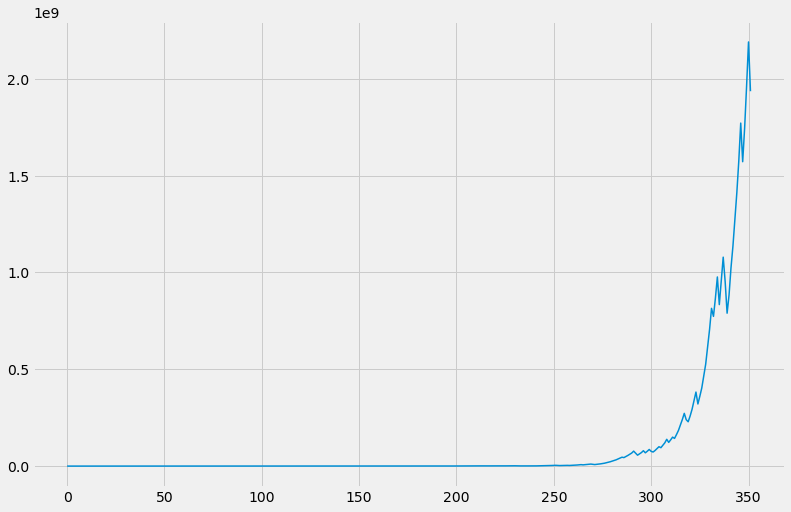

min balance: 47.3733666437402 
max balance: 2190338016.721568 
final balance: 1658646778.5829165 
win percentage 71.02000000000001
(1317, 14)
season 2021
train_accuracy: 0.6727541371158392 test_accuracy: 0.6127562642369021
  probability_range  win_percentage
0      (0.31, 0.69)          0.5875


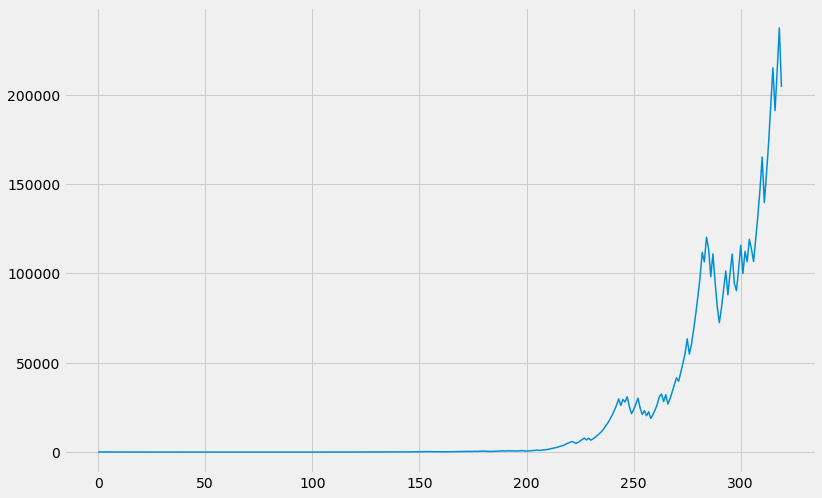

min balance: 6.4765517375421 
max balance: 237361.12370702537 
final balance: 178524.54346992547 
win percentage 58.75
(351, 14)
season 2022
train_accuracy: 0.6669408345670889 test_accuracy: 0.6296296296296297
  probability_range  win_percentage
0      (0.31, 0.69)        0.740741


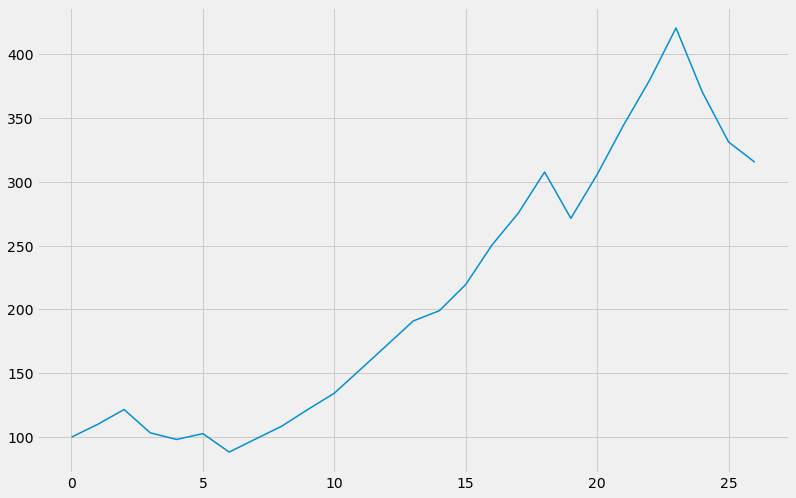

min balance: 88.27824809117612 
max balance: 420.51800151543057 
final balance: 348.1198893207602 
win percentage 74.07000000000001


In [413]:
res = train_model(features1)

In [117]:
#This code uses an NBA_API endpoint to obtain today's games and predicts the result of them. Example modified from NBA_API docs: https://github.com/swar/nba_api/blob/master/docs/examples/LiveData.ipynb

# Query nba.live.endpoints.scoreboard and  list games in localTimeZone
from datetime import datetime, timezone
from dateutil import parser
from nba_api.live.nba.endpoints import scoreboard

f = "{gameId}:  {awayTeam} vs. {homeTeam} @ {gameTimeLTZ}" 

board = scoreboard.ScoreBoard()
print("ScoreBoardDate: " + board.score_board_date)
games = board.games.get_dict()
for game in games:
    gameTimeLTZ = parser.parse(game["gameTimeUTC"]).replace(tzinfo=timezone.utc).astimezone(tz=None)
    print(f.format(gameId=game['gameId'], awayTeam=game['awayTeam']['teamName'], homeTeam=game['homeTeam']['teamName'], gameTimeLTZ=gameTimeLTZ))
    print("Away: " + str(current_elo[game['awayTeam']['teamId']]) + " Home: " + str(current_elo[game['homeTeam']['teamId']]))
    homeTeamPerformance = recentTeamPerformance[game['homeTeam']['teamId']]
    awayTeamPerformance = recentTeamPerformance[game['awayTeam']['teamId']]
    inputList = [current_elo[game['homeTeam']['teamId']],current_elo[game['awayTeam']['teamId']]]
    print('ISORandom Forest Predict: ' + str(isotonicRFC.predict([inputList + homeTeamPerformance + awayTeamPerformance])))
    print('ISORandom Forest Probs: ' +  str(isotonicRFC.predict_proba([inputList + homeTeamPerformance + awayTeamPerformance])))
    print('Random Forest Predict: ' + str(pipelinerf.predict([inputList + homeTeamPerformance + awayTeamPerformance])))
    print('Random Forest Probs: ' +  str(pipelinerf.predict_proba([inputList + homeTeamPerformance + awayTeamPerformance])))
    print('Naive Bayes Predict: ' + str(pipelineNB.predict([inputList + homeTeamPerformance + awayTeamPerformance])))
    print('Naive Bayes Probs: ' + str(pipelineNB.predict_proba([inputList + homeTeamPerformance + awayTeamPerformance])))
    print('\n')

ScoreBoardDate: 2022-12-03
0022200337:  Mavericks vs. Knicks @ 2022-12-03 12:30:00-05:00
Away: 1573.774443533339 Home: 1494.543525415751
ISORandom Forest Predict: [0]
ISORandom Forest Probs: [[0.61580446 0.38419554]]
Random Forest Predict: [0]
Random Forest Probs: [[0.50746857 0.49253143]]
Naive Bayes Predict: [0]
Naive Bayes Probs: [[0.51876582 0.48123418]]


0022200338:  Kings vs. Clippers @ 2022-12-03 16:00:00-05:00
Away: 1526.566155933897 Home: 1491.9252331469684
ISORandom Forest Predict: [1]
ISORandom Forest Probs: [[0.41825445 0.58174555]]
Random Forest Predict: [1]
Random Forest Probs: [[0.42331623 0.57668377]]
Naive Bayes Predict: [1]
Naive Bayes Probs: [[0.44400763 0.55599237]]


0022200339:  Bucks vs. Hornets @ 2022-12-03 18:00:00-05:00
Away: 1578.2058238509642 Home: 1392.2289376324695
ISORandom Forest Predict: [0]
ISORandom Forest Probs: [[0.60619105 0.39380895]]
Random Forest Predict: [1]
Random Forest Probs: [[0.49475865 0.50524135]]
Naive Bayes Predict: [0]
Naive Bayes Pr

Predicting Winners of NBA Games

The project’s goal is to accurately predict whether or not an NBA team wins a given matchup. After researching, it seems the best way to approach this problem is to treat it as a classification problem, since NBA games do not end as a draw, which allows for a binary result.
In order to accomplish this, I have to be able to collect sufficient data, create features from that data that are correlated with the winning potential of a team, and use a tuned model in order to get the best accuracy score. Currently, I have a RandomForest classifier model, and I plan on testing other classifiers like Logistic Regression, K-Nearest Neighbors, and SVM up against it, to see which model will perform the best. After looking at the models, I plan on testing different hyperparameter tuning methods like Grid Search, Random Search and Bayesian Optimization to see which one optimizes the models and results in the most accurate score. I plan on documenting my tests with various graphs and metrics to compare the performance of each model.

Status/Description:

To get the data, I used a data scraping script I found online and used it to scrape game and player data from NBA.com, which scraped game data from the 2003 NBA season all the way to Today’s NBA Games. The scraper resulted in multiple csv files, but the ones I would be interested in would be games.csv, which contains every game’s team stats and box score for the past 20 years, and games_details.csv which provides player stats for each game, based on game ID. Teams.csv and Player.csv contain data on which teamID and playerID correspond with which team and player.
Through research, I found ELO to be one of the best features to use in determining which team wins, since it is a mathematical relationship between the strength of the teams (Beating tougher opponents raises ELO higher), and is reset each season, giving an edge over season trackers like rankings. I used code to calculate the ELO levels of each world cup team to calculate the historical ELO scores of each NBA team before each NBA game in the past 20 years, and updated the scores after each game as well. For each game, I also averaged the teams’ performance in the past 5 games for each game in order to better account for recent team performance in the context of the matchup, and to somewhat account for star player injuries. I currently have two features, the ELOs of the teams and the recent performances of each team.
I currently have a RandomForestClassifier, which gives me an accuracy of 62%, which is pretty good. From what I researched, the best models that predict NBA outcomes are around the 70% mark. I’d like to see how much tuning the model would improve my output by, and whether or not other classification models would perform better. Since I am only using free, publicly available data, I wonder how close I can get the model to 70%, compared to the models that use paid data.

Status:

As for what remains to be done, I would like to include player stats in my model, which would help differentiate what players make a specific team good besides aggregated scores like ELO, which approximate the strength of an entire team. When players get injured for a long period of time (~5+ games), their elo seems to take a hit before the model can determine that the team is weaker. If I include the player stats, hopefully the model can quickly determine the decline of a team due to injury. I would also like to explore basketball metrics like Team offensive and defensive rating, and Player Efficiency Ratings to see if they make a difference in how the model performs. I also wonder if having betting odds would change the performance, as they do reflect well on the probability of a specific match up, however I am not completely sure if it would be a good addition to the ELO feature I have. As stated before, the current model does need to be tuned, and I also plan on comparing the performance of different classification models. I also plan on seeing how standardizing my data would affect the accuracy score.

Code:

My code takes in the data, creates features within the dataframe, and uses it in the model to train it. When my project is complete, most of the code should be the same, however there would be more cells related to the analysis of the models at the bottom, and potentially new cells related to feature creation in the middle.
